# Visualization of Multi-BLEU Scores

## Setup

In [1]:
import json
import re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ROOT = Path("..").resolve()

NB_DIR = ROOT / "notebooks"
MODEL_ROOT = ROOT / "models"
RESULT_DIR = MODEL_ROOT / "results"
SUMMARY_DIR = ROOT / "summary"
IMG_DIR = ROOT / "img"

In [3]:
VARIANT_TO_VERSION = {
    "baseline": 1,
    "change1": 2,
    "change2": 3,
}

EXPERIMENTS = [
    {"model": "seq2seq",     "variant": "baseline", "label": "Seq2Seq baseline",      "has_training": True},
    {"model": "seq2seq",     "variant": "change1",  "label": "Seq2Seq change1",       "has_training": True},
    {"model": "seq2seq",     "variant": "change2",  "label": "Seq2Seq change2",       "has_training": False},
    {"model": "transformer", "variant": "baseline", "label": "Transformer baseline",  "has_training": True},
    {"model": "transformer", "variant": "change1",  "label": "Transformer change1",   "has_training": True},
    {"model": "transformer", "variant": "change2",  "label": "Transformer change2",   "has_training": False},
]

## Training Run Times

### Seq2Seq Models

In [4]:
# baseline
log = MODEL_ROOT / "baseline.seq2seq.myph" / "train.log"
notebook = NB_DIR / "nmt_seq2seq_v1.ipynb"

!grep -m1 "^\[.*\[marian\] Marian" {log}
!grep "Training finished" {log} | tail -1
!jq -r '.cells[].outputs[]?.text[]?' {notebook} | grep '^real' | sed -n '1p'

[2026-05-28 20:57:09] [marian] Marian v1.12.0 65bf82ff 2023-02-21 09:56:29 -0800
[2026-05-29 04:49:53] Training finished
real	472m55.246s


In [5]:
# more frequent checkpointing
log = MODEL_ROOT / "change1.seq2seq.myph" / "train.log"
notebook = NB_DIR / "nmt_seq2seq_v2.ipynb"

!grep "^\[.*\[marian\] Marian" {log}
!grep "Training finished" {log} | tail -1
!jq -r '.cells[].outputs[]?.text[]?' {notebook} | grep '^real' | sed -n '1p'

[2026-05-30 10:47:53] [marian] Marian v1.12.0 65bf82ff 2023-02-21 09:56:29 -0800
[2026-05-30 11:48:11] Training finished
real	60m43.063s


In [6]:
# checkpoint averaging around the peak via ensemble decoding

# NO TRAINING

### Transformer Models

In [7]:
# baseline
log = MODEL_ROOT / "baseline.transformer.myph" / "train.log"
notebook = NB_DIR / "nmt_transformer_v1.ipynb"

!grep "^\[.*\[marian\] Marian" {log}
!grep "Training finished" {log} | tail -1
!jq -r '.cells[].outputs[]?.text[]?' {notebook} | grep '^real' | sed -n '1p'

[2026-05-29 14:28:00] [marian] Marian v1.12.0 65bf82ff 2023-02-21 09:56:29 -0800
[2026-05-29 18:30:20] Training finished
real	242m23.096s


In [8]:
# more frequent checkpointing
log = MODEL_ROOT / "change1.transformer.myph" / "train.log"
notebook = NB_DIR / "nmt_transformer_v2.ipynb"

!grep "^\[.*\[marian\] Marian" {log}
!grep "Training finished" {log} | tail -1
!jq -r '.cells[].outputs[]?.text[]?' {notebook} | grep '^real' | sed -n '1p'

[2026-06-01 07:13:02] [marian] Marian v1.12.0 65bf82ff 2023-02-21 09:56:29 -0800
[2026-06-01 07:58:05] Training finished
real	45m6.420s


In [9]:
# checkpoint averaging around the peak via ensemble decoding

# NO TRAINING

## Decoding Run Times

### Seq2Seq Models

In [10]:
# baseline
notebook = NB_DIR / "nmt_seq2seq_v1.ipynb"

!jq -r '.cells[].outputs[]?.text[]?' {notebook} | grep '^real' | sed -n '2p'

real	0m49.734s


In [11]:
# more frequent checkpointing
notebook = ROOT / "notebooks" / "nmt_seq2seq_v2.ipynb"

!jq -r '.cells[].outputs[]?.text[]?' {notebook} | grep '^real' | sed -n '2p'

real	0m54.698s


In [12]:
# checkpoint averaging around the peak via ensemble decoding
notebook = ROOT / "notebooks" / "nmt_seq2seq_v3.ipynb"

!jq -r '.cells[].outputs[]?.text[]?' {notebook} | grep '^real'

real	1m35.350s


### Transformer Models

In [13]:
# baseline
notebook = NB_DIR / "nmt_transformer_v1.ipynb"

!jq -r '.cells[].outputs[]?.text[]?' {notebook} | grep '^real' | sed -n '2p'

real	0m42.719s


In [14]:
# more frequent checkpointing
notebook = ROOT / "notebooks" / "nmt_transformer_v2.ipynb"

!jq -r '.cells[].outputs[]?.text[]?' {notebook} | grep '^real' | sed -n '2p'

real	0m39.848s


In [15]:
# checkpoint averaging around the peak via ensemble decoding
notebook = ROOT / "notebooks" / "nmt_transformer_v3.ipynb"

!jq -r '.cells[].outputs[]?.text[]?' {notebook} | grep '^real'

real	0m56.421s


## BLEU Scores

In [16]:
!ls {RESULT_DIR}

myph_seq2seq_baseline_result.txt  myph_transformer_baseline_result.txt
myph_seq2seq_change1_result.txt   myph_transformer_change1_result.txt
myph_seq2seq_change2_result.txt   myph_transformer_change2_result.txt


### Seq2Seq Models

In [17]:
# baseline
!cat {RESULT_DIR}/myph_seq2seq_baseline_result.txt

BLEU = 69.49, 85.9/74.0/64.5/57.0 (BP=1.000, ratio=1.000, hyp_len=8044, ref_len=8048)


In [18]:
# more frequent checkpointing
!cat {RESULT_DIR}/myph_seq2seq_change1_result.txt

BLEU = 70.31, 86.1/74.5/65.8/58.1 (BP=0.999, ratio=0.999, hyp_len=8043, ref_len=8048)


In [19]:
# checkpoint averaging around the peak via ensemble decoding
!cat {RESULT_DIR}/myph_seq2seq_change2_result.txt

BLEU = 70.44, 86.2/74.6/65.9/58.2 (BP=0.999, ratio=0.999, hyp_len=8042, ref_len=8048)


### Transformer Models

In [20]:
# baseline
!cat {RESULT_DIR}/myph_transformer_baseline_result.txt

BLEU = 72.44, 87.6/76.6/67.6/61.0 (BP=0.999, ratio=0.999, hyp_len=8041, ref_len=8048)


In [21]:
# more frequent checkpointing
!cat {RESULT_DIR}/myph_transformer_change1_result.txt

BLEU = 71.49, 87.2/75.7/66.5/60.0 (BP=0.998, ratio=0.998, hyp_len=8034, ref_len=8048)


In [22]:
# checkpoint averaging around the peak via ensemble decoding
!cat {RESULT_DIR}/myph_transformer_change2_result.txt

BLEU = 72.35, 87.4/76.3/67.3/61.4 (BP=0.999, ratio=0.999, hyp_len=8036, ref_len=8048)


## Helpers

In [23]:
def notebook_path(model: str, variant: str) -> Path:
    v = VARIANT_TO_VERSION[variant]
    return NB_DIR / f"nmt_{model}_v{v}.ipynb"


def bleu_result_path(model: str, variant: str) -> Path:
    return RESULT_DIR / f"myph_{model}_{variant}_result.txt"

In [24]:
REAL_RE = re.compile(r"^real\s+(?:(\d+)m)?([\d.]+)s\s*$")
MULTI_BLEU_RE = re.compile(r"BLEU = ([\d.]+),")

In [25]:
def parse_real_line(line: str) -> float | None:
    """Parse shell `time` line like 'real\\t472m55.246s'."""
    line = line.strip()
    m = REAL_RE.match(line)
    if not m:
        return None
    mins, secs = m.groups()
    total = float(secs)
    if mins is not None:
        total += int(mins) * 60
    return total


def extract_real_lines(notebook: Path) -> list[str]:
    """Same source as: jq -r '.cells[].outputs[]?.text[]?' | grep '^real'"""
    if not notebook.exists():
        return []

    nb = json.loads(notebook.read_text(encoding="utf-8"))
    lines: list[str] = []

    for cell in nb.get("cells", []):
        for output in cell.get("outputs", []):
            text = output.get("text", [])
            if isinstance(text, str):
                text = [text]
            for chunk in text:
                for line in chunk.splitlines():
                    if line.startswith("real"):
                        lines.append(line)
    return lines


def load_real_seconds(notebook: Path, index: int) -> float | None:
    """1-based index, same as sed -n '{index}p'."""
    lines = extract_real_lines(notebook)
    if index < 1 or index > len(lines):
        return None
    return parse_real_line(lines[index - 1])

In [26]:
def parse_bleu(path: Path) -> float | None:
    if not path.exists():
        return None
    m = MULTI_BLEU_RE.search(path.read_text(encoding="utf-8"))
    return float(m.group(1)) if m else None

In [27]:
def load_experiment_row(cfg: dict) -> dict:
    nb = notebook_path(cfg["model"], cfg["variant"])
    bleu_path = bleu_result_path(cfg["model"], cfg["variant"])

    if cfg.get("has_training", True):
        train_s = load_real_seconds(nb, index=1)
        decode_s = load_real_seconds(nb, index=2)
    else:
        train_s = None
        decode_s = load_real_seconds(nb, index=1)

    return {
        "model": cfg["model"],
        "variant": cfg["variant"],
        "label": cfg["label"],
        "notebook": str(nb),
        "bleu_result": str(bleu_path),
        "training_seconds": train_s,
        "decode_seconds": decode_s,
        "bleu": parse_bleu(bleu_path),
    }


def build_experiment_df(experiments: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame([load_experiment_row(cfg) for cfg in experiments])

    # optional readable columns
    df["training_minutes"] = df["training_seconds"].map(
        lambda s: round(s / 60, 3) if pd.notna(s) else np.nan
    )
    df["training_hours"] = df["training_seconds"].map(
        lambda s: round(s / 3600, 3) if pd.notna(s) else np.nan
    )
    df["decode_seconds"] = df["decode_seconds"].astype("Float64")
    df["bleu"] = df["bleu"].astype("Float64")

    return df

## Transform Scores

In [28]:
df = build_experiment_df(EXPERIMENTS)
df

,model,variant,label,notebook,bleu_result,training_seconds,decode_seconds,bleu,training_minutes,training_hours
0,seq2seq,baseline,Seq2Seq baseline,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,28375.246,49.734,69.49,472.921,7.882
1,seq2seq,change1,Seq2Seq change1,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,3643.063,54.698,70.31,60.718,1.012
2,seq2seq,change2,Seq2Seq change2,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,NaN,95.35,70.44,NaN,NaN
3,transformer,baseline,Transformer baseline,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,14543.096,42.719,72.44,242.385,4.040
4,transformer,change1,Transformer change1,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,2706.420,39.848,71.49,45.107,0.752
5,transformer,change2,Transformer change2,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,NaN,56.421,72.35,NaN,NaN


In [29]:
df.to_csv(SUMMARY_DIR / "time_&_bleu.csv", index=False)

## Visualize

In [30]:
COLORS = {
    "seq2seq": "#17BECF",
    "transformer": "#1E4FA8",
}

In [31]:
df["run"] = df["variant"].map(VARIANT_TO_VERSION)
df["variant"] = pd.Categorical(df["variant"], categories=VARIANT_TO_VERSION, ordered=True)

df = df.sort_values(["run", "model"]).reset_index(drop=True)

# readable x labels
df["xlabel"] = df["model"] + "\n" + df["variant"].astype(str)

In [32]:
df

,model,variant,label,notebook,bleu_result,training_seconds,decode_seconds,bleu,training_minutes,training_hours,run,xlabel
0,seq2seq,baseline,Seq2Seq baseline,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,28375.246,49.734,69.49,472.921,7.882,1,seq2seq\nbaseline
1,transformer,baseline,Transformer baseline,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,14543.096,42.719,72.44,242.385,4.040,1,transformer\nbaseline
2,seq2seq,change1,Seq2Seq change1,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,3643.063,54.698,70.31,60.718,1.012,2,seq2seq\nchange1
3,transformer,change1,Transformer change1,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,2706.420,39.848,71.49,45.107,0.752,2,transformer\nchange1
4,seq2seq,change2,Seq2Seq change2,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,NaN,95.35,70.44,NaN,NaN,3,seq2seq\nchange2
5,transformer,change2,Transformer change2,/home/lawun330/Desktop/basic-neural-machine-tr...,/home/lawun330/Desktop/basic-neural-machine-tr...,NaN,56.421,72.35,NaN,NaN,3,transformer\nchange2


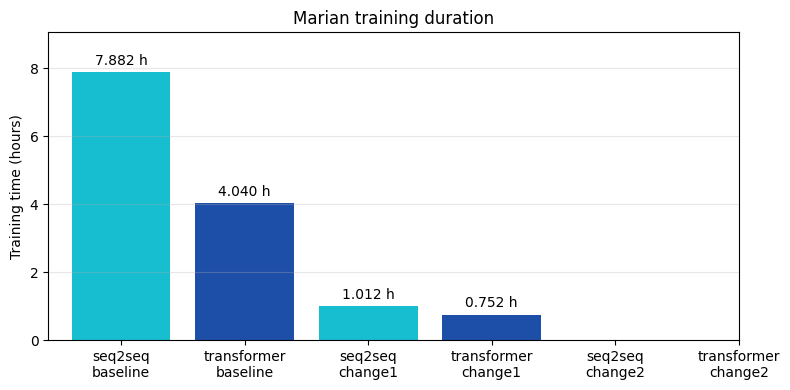

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))

x = range(len(df))
bars = ax.bar(
    x,
    df["training_hours"],
    color=[COLORS[m] for m in df["model"]],
)

ymax = df["training_hours"].max()
ax.set_ylim(0, ymax * 1.15)  # add 15% headroom

ax.set_xticks(x)
ax.set_xticklabels(df["xlabel"], rotation=0)
ax.set_ylabel("Training time (hours)")
ax.set_title("Marian training duration")
ax.bar_label(bars, fmt="%.3f h", padding=3)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(IMG_DIR / "nmt_training_time.png", dpi=150, bbox_inches="tight")

plt.show()

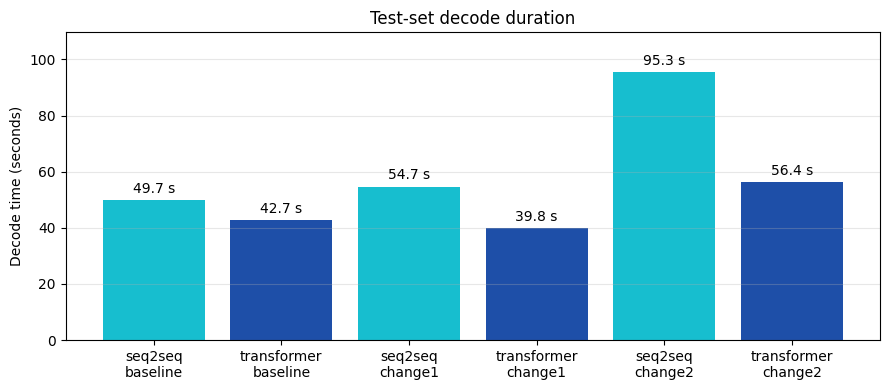

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))

x = range(len(df))
bars = ax.bar(
    x,
    df["decode_seconds"],
    color=[COLORS[m] for m in df["model"]],
)

ymax = df["decode_seconds"].max()
ax.set_ylim(0, ymax * 1.15)  # add 15% headroom

ax.set_xticks(x)
ax.set_xticklabels(df["xlabel"], rotation=0)
ax.set_ylabel("Decode time (seconds)")
ax.set_title("Test-set decode duration")
ax.bar_label(bars, fmt="%.1f s", padding=3)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(IMG_DIR / "nmt_decode_time.png", dpi=150, bbox_inches="tight")

plt.show()

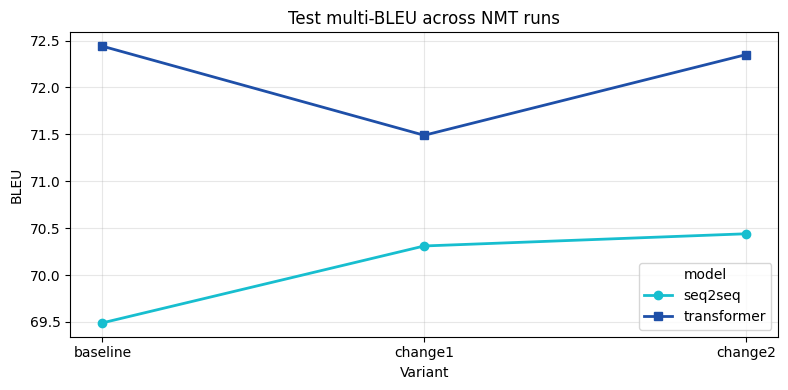

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))

for model, marker in [("seq2seq", "o"), ("transformer", "s")]:
    sub = df[df["model"] == model].sort_values("run")
    ax.plot(
        sub["run"],
        sub["bleu"],
        marker=marker,
        label=model,
        color=COLORS[model],
        linewidth=2,
    )

ticks = sorted(df["run"].unique())
variant_labels = (
    df.drop_duplicates("run")
    .sort_values("run")["variant"]
    .astype(str)
    .tolist()
)

ax.set_xticks(ticks)
ax.set_xticklabels(variant_labels)
ax.set_xlabel("Variant")
ax.set_ylabel("BLEU")
ax.set_title("Test multi-BLEU across NMT runs")
ax.legend(title="model")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(IMG_DIR / "nmt_bleu_lines.png", dpi=150, bbox_inches="tight")

plt.show()

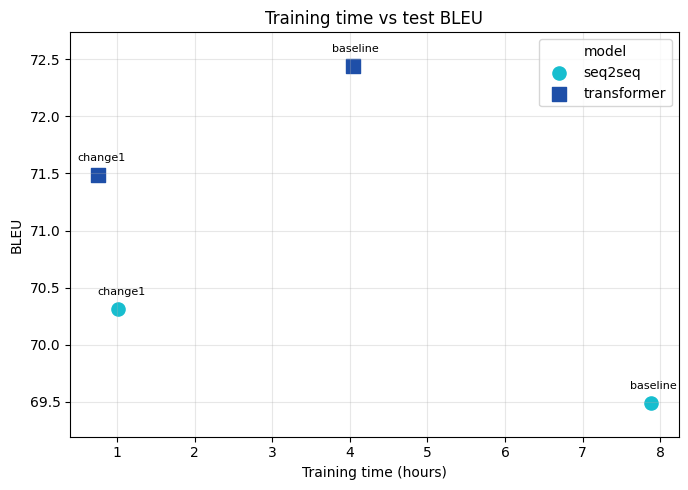

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))

for model, marker in [("seq2seq", "o"), ("transformer", "s")]:
    sub = df[df["model"] == model]
    ax.scatter(
        sub["training_hours"],
        sub["bleu"],
        marker=marker,
        s=90,
        label=model,
        color=COLORS[model],
    )
    for _, row in sub.iterrows():
        ax.annotate(row["variant"], (row["training_hours"], row["bleu"]), fontsize=8, xytext=(-15, 10), textcoords="offset points")

# give headroom
ymin = df["bleu"].min()
ymax = df["bleu"].max()
ypad = (ymax - ymin) * 0.1
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.set_xlabel("Training time (hours)")
ax.set_ylabel("BLEU")
ax.set_title("Training time vs test BLEU")
ax.legend(title="model")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(IMG_DIR / "nmt_training_vs_bleu.png", dpi=150, bbox_inches="tight")

plt.show()

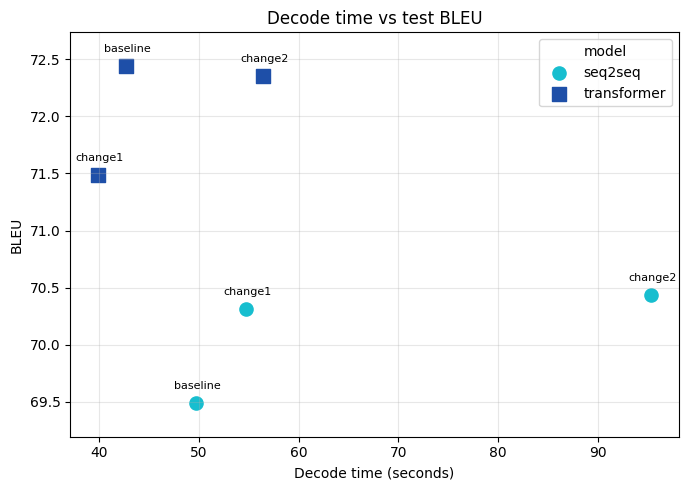

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))

for model, marker in [("seq2seq", "o"), ("transformer", "s")]:
    sub = df[df["model"] == model]
    ax.scatter(
        sub["decode_seconds"],
        sub["bleu"],
        marker=marker,
        s=90,
        label=model,
        color=COLORS[model],
    )
    for _, row in sub.iterrows():
        ax.annotate(row["variant"], (row["decode_seconds"], row["bleu"]), fontsize=8, xytext=(-16, 10), textcoords="offset points")

# give headroom
ymin = df["bleu"].min()
ymax = df["bleu"].max()
ypad = (ymax - ymin) * 0.1
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.set_xlabel("Decode time (seconds)")
ax.set_ylabel("BLEU")
ax.set_title("Decode time vs test BLEU")
ax.legend(title="model")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(IMG_DIR / "nmt_decode_vs_bleu.png", dpi=150, bbox_inches="tight")

plt.show()